## 1. Import all Data needed (Stock price of Apple + Headline)

### Fetch Apple daily stock market value

In [3]:
import yfinance as yf                    # :contentReference[oaicite:3]{index=3}
symbol = "AAPL"
data = yf.download(symbol, start="2023-01-01", end="2025-04-25", interval="1d")
data.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.632538,129.395526,122.742880,128.782657,112117500
2023-01-04,124.907700,127.181268,123.642412,125.431607,89113600
2023-01-05,123.583107,126.301500,123.326101,125.668857,80962700
2023-01-06,128.130219,128.792516,123.454587,124.561717,87754700
2023-01-09,128.654129,131.876670,128.397123,128.970458,70790800


In [4]:
print(data.columns) 

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [5]:
data.columns = data.columns.get_level_values(0)
print(data.columns) 

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


### Fetching Headlines of Apple last 30 Days

In [1]:
from newsapi import NewsApiClient

newsapi = NewsApiClient(api_key='83370559e3de4e2480407d7927f5cbdc')  

In [6]:
# Fetch today’s top headlines mentioning “Apple” in the title
resp = newsapi.get_everything(
    q="Apple",
    from_param="2025-04-01",
    to="2025-04-25",
    language="en",
    sort_by="relevancy",
    page_size=100
)

articles = resp['articles']  # list of dicts with 'publishedAt' and 'title' :contentReference[oaicite:1]{index=1}


In [7]:
headlines = []
for art in articles:
    date = art['publishedAt'][:10]             # e.g. "2025-04-23"
    text = art['title']
    headlines.append((date, text))

In [8]:
headlines

[('2025-04-23',
  'The EU isn’t happy with Apple’s tax on alternative app stores'),
 ('2025-04-24', "The Apple Watch Turns 10. Here's How Far It's Come"),
 ('2025-04-02', 'Apple stumbles with latest AirPods Max firmware'),
 ('2025-04-24', '22 Best MacBook Accessories (2025), Tested and Reviewed'),
 ('2025-04-03',
  'Apple has its biggest stock drop in five years because of Trump’s tariffs'),
 ('2025-04-10',
  'Apple quickly shipped 600 tons of iPhones to ‘beat’ the new tariffs'),
 ('2025-04-03',
  'Apple has its biggest stock drop in five years because of Trump’s tariffs'),
 ('2025-04-08',
  'You can grab three months of Apple TV Plus for $2.99 a month right now'),
 ('2025-04-16',
  'Google, Apple, and Snap aren’t happy about Meta’s poorly-redacted slides'),
 ('2025-04-23',
  'Did Tim Cook finagle a special tariff deal? Senator Warren wants to know'),
 ('2025-04-14',
  'Apple’s complicated plan to improve its AI while protecting privacy'),
 ('2025-04-18',
  'Apple replaced Mythic Quest

## 2. Using a Finance-Tuned Sentiment Model (NLP)

In [9]:
from transformers import pipeline

# Use the ProsusAI/finbert model fine-tuned on financial news :contentReference[oaicite:3]{index=3}
finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert"
)


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


### Applying Sentiment to Your Headlines

In [10]:
import pandas as pd

dates, scores = [], []
for date, text in headlines:
    res = finbert(text[:512])[0]
    # Positive label → positive score; negative → negative score
    score = res['score'] if res['label']=="positive" else -res['score']
    dates.append(date)
    scores.append(score)

sent_df = pd.DataFrame(
    {"sentiment": scores},
    index=pd.to_datetime(dates)
)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [11]:
sent_df.head()

,sentiment
2025-04-23,-0.875781
2025-04-24,-0.886733
2025-04-02,-0.908276
2025-04-24,-0.687817
2025-04-03,-0.964225


### Integrating Sentiment with Price Data

In [12]:
# Assuming `data` from yfinance
df = data[['Close']].join(sent_df).fillna(0)
df['sent_ma'] = df['sentiment'].rolling(window=3).mean()

In [14]:
df.tail()

,Close,sentiment,sent_ma
Date,,,
2025-04-24,208.369995,-0.687817,-0.833327
2025-04-24,208.369995,-0.950305,-0.841618
2025-04-24,208.369995,-0.934954,-0.857692
2025-04-24,208.369995,-0.762419,-0.882559
2025-04-24,208.369995,-0.731597,-0.809656


## 3. Use Backtrader to run a trading strategy based on the sentiment data

This here prepares the data (the params needed from dt frame, -1 fill automatically from name) in an organized way for the backtest. 

In [27]:
import backtrader as bt  # Backtrader framework for strategy backtesting

class SentPandas(bt.feeds.PandasData):
    """
    Custom data feed extending Backtrader's PandasData to include:
      - sentiment: raw sentiment values
      - sent_ma: moving average of sentiment
    Alongside standard OHLC data.
    """
    lines = ('sentiment', 'sent_ma',)
    params = (
        ('dataname',     None),               # Pandas DataFrame source
        ('timeframe',    bt.TimeFrame.Days),  # Daily data
        ('compression',  1),                  # No compression
        ('datetime',     None),               # Use DataFrame index for dates
        ('open',         'Close'),            # Map open price to 'Close' column
        ('high',         'Close'),            # Map high price to 'Close' column
        ('low',          'Close'),            # Map low price to 'Close' column
        ('close',        'Close'),            # Map close price to 'Close' column
        ('volume',       -1),                 # No volume column
        ('openinterest', -1),                 # No open interest column
        ('sentiment',    'sentiment'),        # Column name for sentiment line
        ('sent_ma',      'sent_ma'),          # Column name for sentiment MA line
    )

### Strategy Definition

In [32]:
class DebugSentEMAStrat(bt.Strategy):
    """
    Strategy that trades based on the EMA of sentiment:
      - Buys when EMA crosses above enter_th
      - Sells (closes) when EMA crosses below exit_th
    """
    params = dict(
        ema_period=3,   # Lookback period for EMA calculation
        enter_th=-0.4,  # EMA threshold to enter a long position
        exit_th=-0.5    # EMA threshold to exit/close the position
    )

    def __init__(self):
        # Compute EMA of the sentiment line
        self.ema_sent = bt.ind.EMA(self.data.sentiment, period=self.p.ema_period)
        # Signal: EMA crossing above the enter threshold
        self.up_cross = bt.ind.CrossOver(self.ema_sent, self.p.enter_th)
        # Signal: EMA crossing below the exit threshold
        self.down_cross = bt.ind.CrossDown(self.ema_sent, self.p.exit_th)

    def next(self):
        """
        Called on each new data bar:
          - Logs date, close price, cash, current position size,
            EMA value, and crossover signals.
          - Submits buy orders when up_cross > 0 and no open position.
          - Submits sell (close) orders when down_cross > 0 and a position exists.
        """
        dt    = bt.num2date(self.data.datetime[0])   # Current date
        price = self.data.close[0]                   # Current closing price
        cash  = self.broker.getcash()                # Available cash
        pos   = self.position.size if self.position else 0  # Current position size

        # Log the current state
        print(
            f"{dt.date()}  Close={price:.2f}  Cash={cash:.2f}  "
            f"Pos={pos}  EMA={self.ema_sent[0]:.3f}  "
            f"UpX={self.up_cross[0]}  DnX={self.down_cross[0]}"
        )

        # Enter long: no position and EMA crosses above enter_th
        if not self.position and self.up_cross > 0:
            size = int((cash * 0.5) / price)  # Allocate 50% of cash
            print(f"  → SUBMIT BUY size={size}")
            self.buy(size=size)

        # Exit long: position exists and EMA crosses below exit_th
        elif self.position and self.down_cross > 0:
            print(f"  → SUBMIT SELL size={self.position.size}")
            self.close()

    def notify_order(self, order):
        """
        Called when an order's status changes:
          - Ignores Submitted/Accepted statuses.
          - Logs execution details once the order is completed.
        """
        if order.status in {order.Submitted, order.Accepted}:
            return

        dt   = bt.num2date(order.created.dt)          # Order creation date
        side = 'BUY' if order.isbuy() else 'SELL'
        print(
            f"{dt.date()}  ORDER {side} "
            f"STATUS={order.Status[order.status]}  "
            f"Price={order.executed.price}  "
            f"Size={order.executed.size}"
        )

    def notify_trade(self, trade):
        """
        Called when a trade is closed:
          - Logs the profit or loss for the completed trade.
        """
        if not trade.isclosed:
            return
        print(f"TRADE CLOSED: PnL={trade.pnl:.2f}")

### Backtest Execution & Analyzers

In [33]:
# Run it
test_df = df['2025-04-01':'2025-04-25']
cerebro = bt.Cerebro()
cerebro.broker.setcash(50_000)
cerebro.adddata(SentPandas(dataname=test_df, timeframe=bt.TimeFrame.Days, compression=1))
cerebro.addstrategy(DebugSentEMAStrat)
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(bt.analyzers.DrawDown,     _name='drawdown')
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer,_name='trades')
cerebro.addanalyzer(bt.analyzers.TimeReturn,_name='timereturn')


results = cerebro.run()
strat   = results[0]

2025-04-02  Close=223.89  Cash=50000.00  Pos=0  EMA=-0.866  UpX=0.0  DnX=0.0
2025-04-02  Close=223.89  Cash=50000.00  Pos=0  EMA=-0.899  UpX=0.0  DnX=0.0
2025-04-02  Close=223.89  Cash=50000.00  Pos=0  EMA=-0.776  UpX=0.0  DnX=0.0
2025-04-02  Close=223.89  Cash=50000.00  Pos=0  EMA=-0.867  UpX=0.0  DnX=0.0
2025-04-02  Close=223.89  Cash=50000.00  Pos=0  EMA=-0.855  UpX=0.0  DnX=0.0
2025-04-02  Close=223.89  Cash=50000.00  Pos=0  EMA=-0.855  UpX=0.0  DnX=0.0
2025-04-03  Close=203.19  Cash=50000.00  Pos=0  EMA=-0.910  UpX=0.0  DnX=0.0
2025-04-03  Close=203.19  Cash=50000.00  Pos=0  EMA=-0.937  UpX=0.0  DnX=0.0
2025-04-03  Close=203.19  Cash=50000.00  Pos=0  EMA=-0.917  UpX=0.0  DnX=0.0
2025-04-03  Close=203.19  Cash=50000.00  Pos=0  EMA=-0.924  UpX=0.0  DnX=0.0
2025-04-04  Close=188.38  Cash=50000.00  Pos=0  EMA=-0.851  UpX=0.0  DnX=0.0
2025-04-04  Close=188.38  Cash=50000.00  Pos=0  EMA=-0.732  UpX=0.0  DnX=0.0
2025-04-07  Close=181.46  Cash=50000.00  Pos=0  EMA=-0.800  UpX=0.0  DnX=0.0

### Visualization 

In [34]:
#  Get the analyzer
ta = strat.analyzers.getbyname('trades').get_analysis()

#  Safe extraction with defaults
total_closed = getattr(ta.total, 'closed', 0)
won_total    = getattr(ta.won,   'total',  0)
lost_total   = getattr(ta.lost,  'total',  0)
pnl_net      = getattr(getattr(ta.pnl, 'net', ta.pnl), 'total', 0)

win_rate = (won_total / total_closed) if total_closed else 0.0

print(f"Total Trades: {total_closed}")
print(f"  Won:         {won_total}")
print(f"  Lost:        {lost_total}")
print(f"Net P&L:      ${pnl_net:,.2f}")
print(f"Win Rate:     {win_rate:.2%}")


Total Trades: 2
  Won:         2
  Lost:        0
Net P&L:      $4,179.51
Win Rate:     100.00%


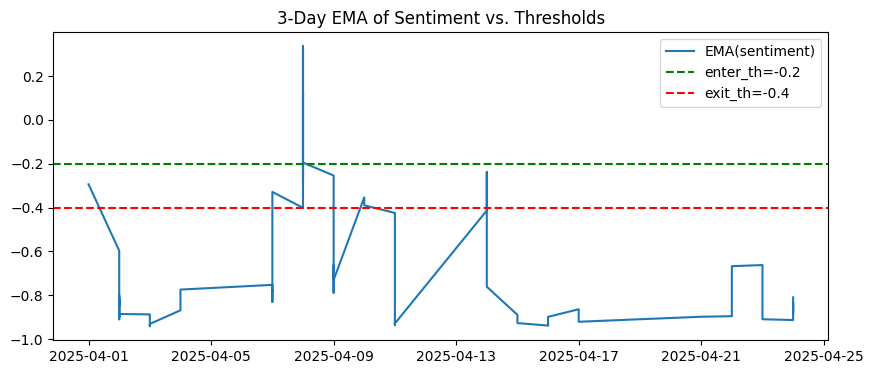

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(test_df.index, test_df['sent_ma'], label='EMA(sentiment)')
ax.axhline(-0.2, color='green', linestyle='--', label='enter_th=-0.2')
ax.axhline(-0.4, color='red',   linestyle='--', label='exit_th=-0.4')
ax.set_title("3-Day EMA of Sentiment vs. Thresholds")
ax.legend()
plt.show()


<IPython.core.display.Javascript object>


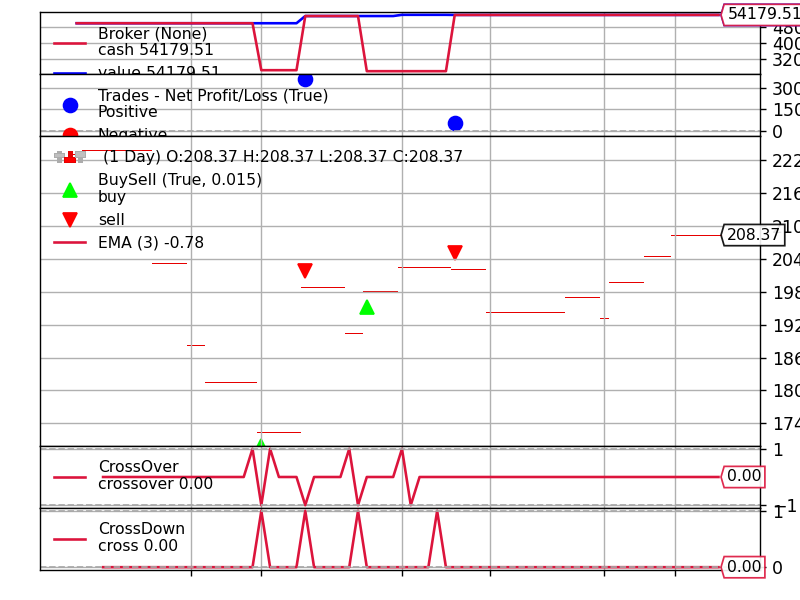

[[<Figure size 640x480 with 5 Axes>]]

In [112]:
cerebro.plot(open=False, high=False, low=False, volume=False)

### Compare to Buy-and-Hold

In [24]:
# Buy-and-Hold return over the same window
bh_start = test_df['Close'].iloc[0]
bh_end   = test_df['Close'].iloc[-1]
bh_ret   = bh_end / bh_start - 1
print(f"Buy-and-Hold: start={bh_start:.2f}, end={bh_end:.2f}, return={bh_ret:.2%}")

Buy-and-Hold: start=223.19, end=208.37, return=-6.64%


Apr 7 → Apr 8: Buy 137 @ $172.42, Sell @ $198.85 → PnL $3 620.91

Apr 10 → Apr 14: Buy 140 @ $198.15, Sell @ $202.14 → PnL $558.60

Ending cash: $54 179.51 starting from $50 000 → +8.36% over 26 trading days.


On April 2 you saw Close=223.89, and on April 24 it was 208.37, so buy-and-hold lost about -6.98%. Your strategy’s +8.36% vs -6.98% yields α ≈ 15.34% over those weeks